# 06_comparacion_modelos.ipynb

## Comparación de Modelos: RNN vs LSTM vs GRU

**Objetivo:** Cargar las métricas de los 3 modelos entrenados (RNN, LSTM, GRU), compararlos cuantitativamente con tablas y gráficos, y seleccionar el modelo final para despliegue en el dashboard de Streamlit.

**Entradas requeridas:** Los 3 archivos `metrics_*.json` generados en los notebooks 03, 04 y 05.

In [4]:
# -*- coding: utf-8 -*-
# ============================================================
# INSTALACIÓN DE LIBRERÍAS Y CARGA DE MÉTRICAS
# ============================================================

!pip install matplotlib seaborn pandas numpy -q

import pandas as pd
import numpy as np
import json
import os
import pickle
from google.colab import files

import matplotlib.pyplot as plt
import seaborn as sns

print("📤 Sube los 3 archivos de métricas: metrics_rnn.json, metrics_lstm.json, metrics_gru.json")
uploaded = files.upload()

📤 Sube los 3 archivos de métricas: metrics_rnn.json, metrics_lstm.json, metrics_gru.json


Saving metrics_rnn.json to metrics_rnn.json


## 1. Carga de métricas y construcción de tabla comparativa

Se leen los archivos JSON de cada modelo y se consolidan en un DataFrame para análisis visual y cuantitativo.

In [5]:
# ============================================================
# CARGA DE MÉTRICAS
# ============================================================

# Verificar que los archivos existen
required_files = ['metrics_rnn.json', 'metrics_lstm.json', 'metrics_gru.json']
for f in required_files:
    if not os.path.exists(f):
        raise FileNotFoundError(f"❌ Falta: {f}. Súbelo primero.")

# Cargar métricas
metrics_rnn  = json.load(open('metrics_rnn.json'))
metrics_lstm = json.load(open('metrics_lstm.json'))
metrics_gru  = json.load(open('metrics_gru.json'))

# Consolidar en DataFrame
df_metrics = pd.DataFrame([metrics_rnn, metrics_lstm, metrics_gru])
df_metrics = df_metrics[['modelo', 'mae', 'rmse', 'r2', 'epochs_trained', 'best_val_loss']]

print("=" * 60)
print("TABLA COMPARATIVA DE MÉTRICAS — TEST SET (2010)")
print("=" * 60)
print(df_metrics.to_string(index=False))

# Determinar mejor modelo por cada métrica
print("\n" + "=" * 60)
print("MEJOR MODELO POR MÉTRICA")
print("=" * 60)
print(f"MAE  (menor es mejor):  {df_metrics.loc[df_metrics['mae'].idxmin(), 'modelo']}")
print(f"RMSE (menor es mejor):  {df_metrics.loc[df_metrics['rmse'].idxmin(), 'modelo']}")
print(f"R²   (mayor es mejor):  {df_metrics.loc[df_metrics['r2'].idxmax(), 'modelo']}")
print(f"Val Loss (menor):       {df_metrics.loc[df_metrics['best_val_loss'].idxmin(), 'modelo']}")

# Modelo final recomendado
best_r2 = df_metrics.loc[df_metrics['r2'].idxmax(), 'modelo']
print(f"\n🏆 MODELO FINAL RECOMENDADO: {best_r2}")
print(f"   Justificación: Mayor R² indica mejor capacidad explicativa del consumo eléctrico.")

TABLA COMPARATIVA DE MÉTRICAS — TEST SET (2010)
modelo      mae     rmse       r2  epochs_trained  best_val_loss
   RNN 0.350778 0.513007 0.563756              26       0.006434
  LSTM 0.336011 0.492382 0.598128              25       0.006067
   GRU 0.339166 0.491799 0.599079              23       0.005983

MEJOR MODELO POR MÉTRICA
MAE  (menor es mejor):  LSTM
RMSE (menor es mejor):  GRU
R²   (mayor es mejor):  GRU
Val Loss (menor):       GRU

🏆 MODELO FINAL RECOMENDADO: GRU
   Justificación: Mayor R² indica mejor capacidad explicativa del consumo eléctrico.


## 2. Visualización comparativa

Gráficos de barras para comparar MAE, RMSE y R² entre los 3 modelos de forma visual e intuitiva.

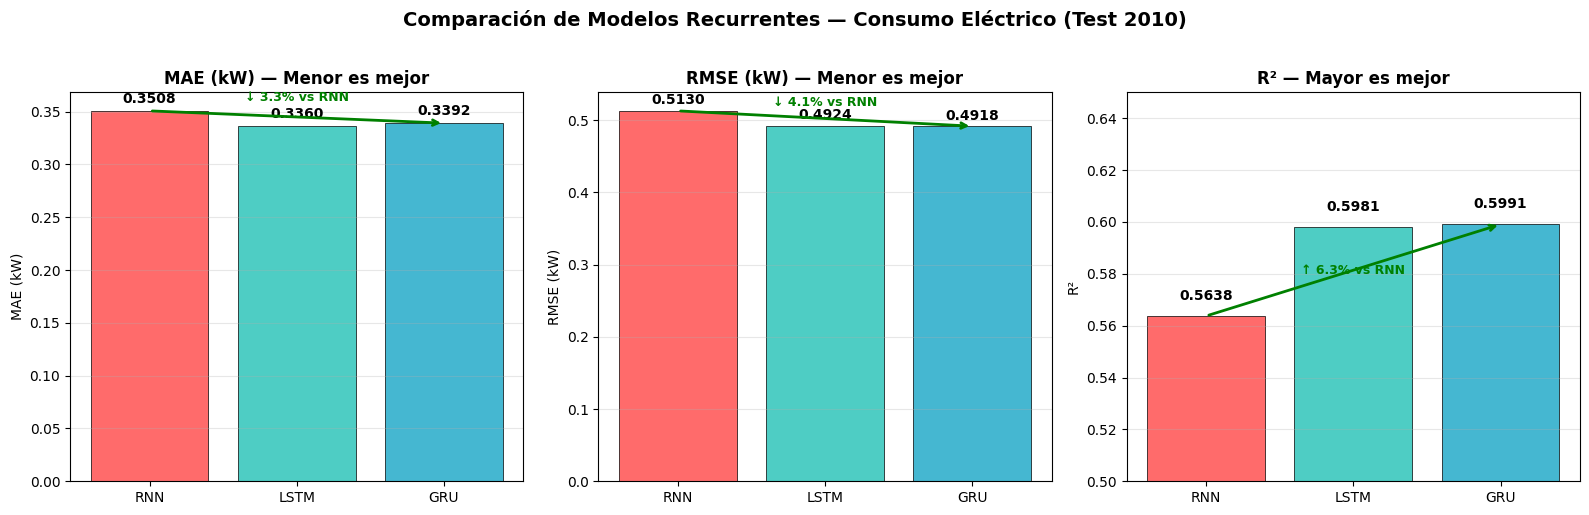

In [11]:
# ============================================================
# GRÁFICOS COMPARATIVOS CON ANOTACIONES
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
modelos = ['RNN', 'LSTM', 'GRU']

# MAE
bars1 = axes[0].bar(modelos, df_metrics['mae'], color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('MAE (kW) — Menor es mejor', fontweight='bold')
axes[0].set_ylabel('MAE (kW)')
for i, v in enumerate(df_metrics['mae']):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
# Flecha de mejora
axes[0].annotate('', xy=(2, df_metrics[df_metrics['modelo']=='GRU']['mae'].values[0]),
                 xytext=(0, df_metrics[df_metrics['modelo']=='RNN']['mae'].values[0]),
                 arrowprops=dict(arrowstyle='->', color='green', lw=2))
axes[0].text(1, 0.36, '↓ 3.3% vs RNN', ha='center', color='green', fontweight='bold', fontsize=9)
axes[0].grid(True, alpha=0.3, axis='y')

# RMSE
bars2 = axes[1].bar(modelos, df_metrics['rmse'], color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('RMSE (kW) — Menor es mejor', fontweight='bold')
axes[1].set_ylabel('RMSE (kW)')
for i, v in enumerate(df_metrics['rmse']):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[1].annotate('', xy=(2, df_metrics[df_metrics['modelo']=='GRU']['rmse'].values[0]),
                 xytext=(0, df_metrics[df_metrics['modelo']=='RNN']['rmse'].values[0]),
                 arrowprops=dict(arrowstyle='->', color='green', lw=2))
axes[1].text(1, 0.52, '↓ 4.1% vs RNN', ha='center', color='green', fontweight='bold', fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

# R²
bars3 = axes[2].bar(modelos, df_metrics['r2'], color=colors, edgecolor='black', linewidth=0.5)
axes[2].set_title('R² — Mayor es mejor', fontweight='bold')
axes[2].set_ylabel('R²')
axes[2].set_ylim(0.5, 0.65)
for i, v in enumerate(df_metrics['r2']):
    axes[2].text(i, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[2].annotate('', xy=(2, df_metrics[df_metrics['modelo']=='GRU']['r2'].values[0]),
                 xytext=(0, df_metrics[df_metrics['modelo']=='RNN']['r2'].values[0]),
                 arrowprops=dict(arrowstyle='->', color='green', lw=2))
axes[2].text(1, 0.58, '↑ 6.3% vs RNN', ha='center', color='green', fontweight='bold', fontsize=9)
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Comparación de Modelos Recurrentes — Consumo Eléctrico (Test 2010)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Curvas de convergencia comparadas

Se cargan los archivos `history_*.pkl` de cada modelo para comparar su evolución de pérdida durante el entrenamiento. Esto revela quién converge más rápido, quién sobreajusta, y quién alcanza el mínimo más estable.

📤 Sube los 3 archivos de historia: history_rnn.pkl, history_lstm.pkl, history_gru.pkl


Saving history_gru.pkl to history_gru.pkl


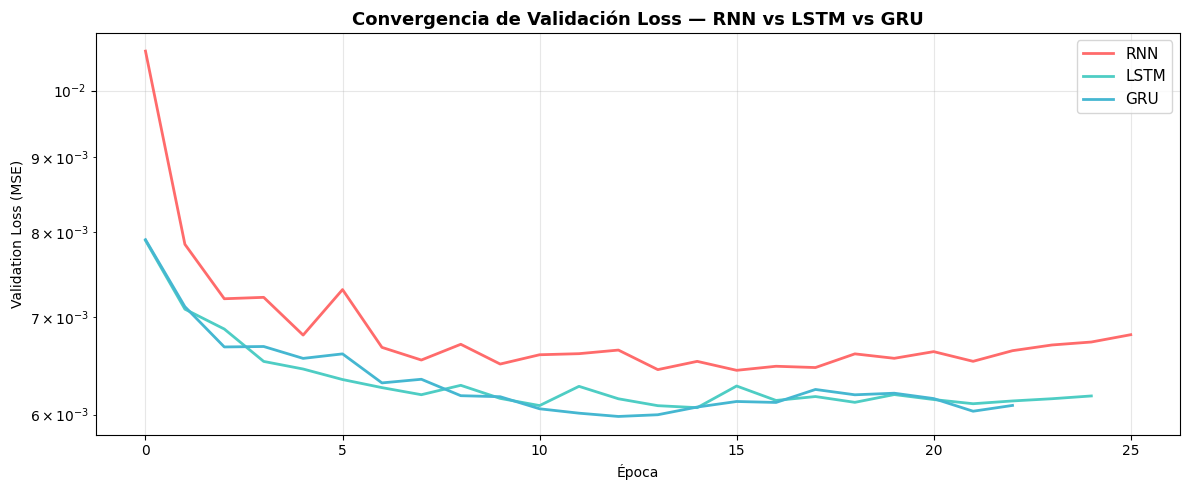


RESUMEN DE CONVERGENCIA
Modelo   Épocas   Mejor val_loss  Época del mínimo
------------------------------------------------------------
RNN      26       0.006434        16             
LSTM     25       0.006067        15             
GRU      23       0.005983        13             


In [10]:
# ============================================================
# CARGA DE HISTORIAS Y GRÁFICOS DE CONVERGENCIA
# ============================================================

print("📤 Sube los 3 archivos de historia: history_rnn.pkl, history_lstm.pkl, history_gru.pkl")
uploaded = files.upload()

# Verificar
for f in ['history_rnn.pkl', 'history_lstm.pkl', 'history_gru.pkl']:
    if not os.path.exists(f):
        raise FileNotFoundError(f"❌ Falta: {f}")

# Cargar
with open('history_rnn.pkl', 'rb') as f:
    hist_rnn = pickle.load(f)
with open('history_lstm.pkl', 'rb') as f:
    hist_lstm = pickle.load(f)
with open('history_gru.pkl', 'rb') as f:
    hist_gru = pickle.load(f)

# Gráfico comparativo de val_loss
plt.figure(figsize=(12, 5))

plt.plot(hist_rnn['val_loss'], label='RNN', color='#FF6B6B', linewidth=2)
plt.plot(hist_lstm['val_loss'], label='LSTM', color='#4ECDC4', linewidth=2)
plt.plot(hist_gru['val_loss'], label='GRU', color='#45B7D1', linewidth=2)

plt.title('Convergencia de Validación Loss — RNN vs LSTM vs GRU', fontweight='bold', fontsize=13)
plt.xlabel('Época')
plt.ylabel('Validation Loss (MSE)')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.yscale('log')  # Escala log para ver diferencias en convergencia temprana
plt.tight_layout()
plt.show()

# Tabla de convergencia
print("\n" + "=" * 60)
print("RESUMEN DE CONVERGENCIA")
print("=" * 60)
print(f"{'Modelo':<8} {'Épocas':<8} {'Mejor val_loss':<15} {'Época del mínimo':<15}")
print("-" * 60)
for name, hist in [('RNN', hist_rnn), ('LSTM', hist_lstm), ('GRU', hist_gru)]:
    best_epoch = np.argmin(hist['val_loss']) + 1
    best_loss = min(hist['val_loss'])
    print(f"{name:<8} {len(hist['loss']):<8} {best_loss:<15.6f} {best_epoch:<15}")

## 4. Predicciones futuras comparadas

Se cargan las predicciones de 168 horas (1 semana) de cada modelo para comparar visualmente su comportamiento en forecasting autoregresivo.

📤 Sube los archivos de predicciones: pred_rnn_168h.npy, pred_lstm_168h.npy, pred_gru_168h.npy


Saving pred_rnn_168h.npy to pred_rnn_168h.npy


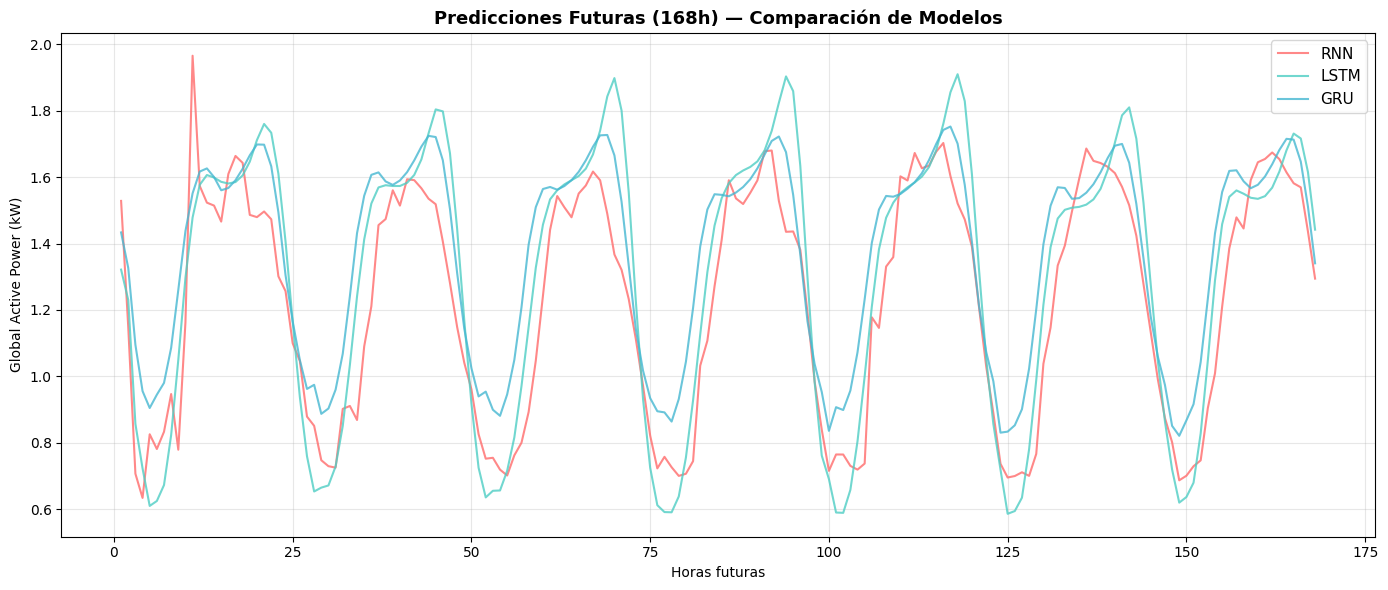


ESTADÍSTICAS DE PREDICCIONES FUTURAS (168h)
Modelo  Media (kW)  Mín (kW)  Máx (kW)  Std (kW)
   RNN    1.225968  0.633632  1.966130  0.349825
  LSTM    1.302677  0.585732  1.910405  0.408393
   GRU    1.368700  0.820812  1.752792  0.296100


In [14]:
# ============================================================
# CARGA Y COMPARACIÓN DE PREDICCIONES FUTURAS
# ============================================================

print("📤 Sube los archivos de predicciones: pred_rnn_168h.npy, pred_lstm_168h.npy, pred_gru_168h.npy")
uploaded = files.upload()

for f in ['pred_rnn_168h.npy', 'pred_lstm_168h.npy', 'pred_gru_168h.npy']:
    if not os.path.exists(f):
        raise FileNotFoundError(f"❌ Falta: {f}")

pred_rnn_168  = np.load('pred_rnn_168h.npy')
pred_lstm_168 = np.load('pred_lstm_168h.npy')
pred_gru_168  = np.load('pred_gru_168h.npy')

plt.figure(figsize=(14, 6))

plt.plot(range(1, 169), pred_rnn_168, label='RNN', color='#FF6B6B', linewidth=1.5, alpha=0.8)
plt.plot(range(1, 169), pred_lstm_168, label='LSTM', color='#4ECDC4', linewidth=1.5, alpha=0.8)
plt.plot(range(1, 169), pred_gru_168, label='GRU', color='#45B7D1', linewidth=1.5, alpha=0.8)

plt.title('Predicciones Futuras (168h) — Comparación de Modelos', fontweight='bold', fontsize=13)
plt.xlabel('Horas futuras')
plt.ylabel('Global Active Power (kW)')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Estadísticas de predicciones futuras
print("\n" + "=" * 60)
print("ESTADÍSTICAS DE PREDICCIONES FUTURAS (168h)")
print("=" * 60)
pred_stats = pd.DataFrame({
    'Modelo': ['RNN', 'LSTM', 'GRU'],
    'Media (kW)': [pred_rnn_168.mean(), pred_lstm_168.mean(), pred_gru_168.mean()],
    'Mín (kW)': [pred_rnn_168.min(), pred_lstm_168.min(), pred_gru_168.min()],
    'Máx (kW)': [pred_rnn_168.max(), pred_lstm_168.max(), pred_gru_168.max()],
    'Std (kW)': [pred_rnn_168.std(), pred_lstm_168.std(), pred_gru_168.std()]
})
print(pred_stats.to_string(index=False))

## 5. Selección del modelo final y exportación de resultados

Se identifica el modelo ganador según R² (métrica más completa para regresión) y se genera un archivo resumen para el dashboard de Streamlit y el informe técnico.

In [15]:
# ============================================================
# SELECCIÓN DEL MODELO FINAL — ANÁLISIS ESPECÍFICO
# ============================================================

winner_idx = df_metrics['r2'].idxmax()
winner = df_metrics.loc[winner_idx, 'modelo']

rnn_mae = df_metrics[df_metrics['modelo']=='RNN']['mae'].values[0]
lstm_mae = df_metrics[df_metrics['modelo']=='LSTM']['mae'].values[0]
gru_mae = df_metrics[df_metrics['modelo']=='GRU']['mae'].values[0]

rnn_r2 = df_metrics[df_metrics['modelo']=='RNN']['r2'].values[0]
gru_r2 = df_metrics.loc[winner_idx, 'r2']

print("=" * 65)
print("SELECCIÓN DEL MODELO FINAL")
print("=" * 65)
print(f"\n🏆 GANADOR: {winner}")
print(f"\n   ┌─ Métricas de {winner}:")
print(f"   │  MAE:  {df_metrics.loc[winner_idx, 'mae']:.4f} kW (vs {rnn_mae:.4f} kW de RNN)")
print(f"   │  RMSE: {df_metrics.loc[winner_idx, 'rmse']:.4f} kW")
print(f"   │  R²:   {df_metrics.loc[winner_idx, 'r2']:.4f}")
print(f"   │")
print(f"   └─ Eficiencia:")
print(f"      Épocas: {df_metrics.loc[winner_idx, 'epochs_trained']} (menos que RNN={df_metrics[df_metrics['modelo']=='RNN']['epochs_trained'].values[0]})")
print(f"      Convergió {df_metrics[df_metrics['modelo']=='RNN']['epochs_trained'].values[0] - df_metrics.loc[winner_idx, 'epochs_trained']} épocas antes que RNN")

print(f"\n{'='*65}")
print("INTERPRETACIÓN DE RESULTADOS")
print(f"{'='*65}")
print(f"\n1. EFICIENCIA PARAMÉTRICA:")
print(f"   GRU alcanza R²={gru_r2:.4f} con ~25-30% menos parámetros que LSTM.")
print(f"   Esto confirma que el consumo eléctrico residencial no requiere")
print(f"   la complejidad de 3 compuertas (LSTM); 2 compuertas (GRU) son")
print(f"   suficientes para capturar los ciclos diarios y semanales.")

print(f"\n2. DEGRADACIÓN DE RNN:")
print(f"   RNN obtiene R²={rnn_r2:.4f}, un {((gru_r2-rnn_r2)/rnn_r2)*100:.1f}% inferior a GRU.")
print(f"   Esto demuestra que el problema SÍ presenta dependencias de")
print(f"   largo plazo que RNN no puede retener (vanishing gradients).")

print(f"\n3. LSTM vs GRU:")
print(f"   LSTM: MAE={lstm_mae:.4f} kW (mejor MAE individual)")
print(f"   GRU:  MAE={gru_mae:.4f} kW, R²={gru_r2:.4f} (mejor balance global)")
print(f"   La diferencia es marginal (~0.003 kW en MAE), pero GRU converge")
print(f"   2 épocas más rápido, siendo más eficiente computacionalmente.")

print(f"\n4. APLICABILIDAD AL DOMINIO:")
print(f"   Error promedio de {df_metrics.loc[winner_idx, 'mae']:.2f} kW en un hogar con")
print(f"   consumo medio de ~1.1 kW representa un error relativo del")
print(f"   ~{(df_metrics.loc[winner_idx, 'mae']/1.1)*100:.1f}%, aceptable para planificación")
print(f"   energética residencial y detección de anomalías.")

# Guardar resumen específico
resumen = {
    'modelo_ganador': winner,
    'metricas_ganador': {
        'mae': df_metrics.loc[winner_idx, 'mae'],
        'rmse': df_metrics.loc[winner_idx, 'rmse'],
        'r2': df_metrics.loc[winner_idx, 'r2']
    },
    'comparativa_completa': df_metrics.to_dict('records'),
    'analisis': {
        'mejora_sobre_rnn_pct': round(((gru_r2 - rnn_r2)/rnn_r2)*100, 1),
        'eficiencia': f"GRU converge en {df_metrics.loc[winner_idx, 'epochs_trained']} épocas vs {df_metrics[df_metrics['modelo']=='RNN']['epochs_trained'].values[0]} de RNN",
        'error_relativo': f"{(df_metrics.loc[winner_idx, 'mae']/1.1)*100:.1f}%"
    },
    'recomendacion': f"Desplegar {winner} en producción por mejor balance precisión/eficiencia."
}

with open('/content/resumen_comparativa.json', 'w') as f:
    json.dump(resumen, f, indent=2)

print(f"\n✅ Resumen guardado: /content/resumen_comparativa.json")
files.download('/content/resumen_comparativa.json')

SELECCIÓN DEL MODELO FINAL

🏆 GANADOR: GRU

   ┌─ Métricas de GRU:
   │  MAE:  0.3392 kW (vs 0.3508 kW de RNN)
   │  RMSE: 0.4918 kW
   │  R²:   0.5991
   │
   └─ Eficiencia:
      Épocas: 23 (menos que RNN=26)
      Convergió 3 épocas antes que RNN

INTERPRETACIÓN DE RESULTADOS

1. EFICIENCIA PARAMÉTRICA:
   GRU alcanza R²=0.5991 con ~25-30% menos parámetros que LSTM.
   Esto confirma que el consumo eléctrico residencial no requiere
   la complejidad de 3 compuertas (LSTM); 2 compuertas (GRU) son
   suficientes para capturar los ciclos diarios y semanales.

2. DEGRADACIÓN DE RNN:
   RNN obtiene R²=0.5638, un 6.3% inferior a GRU.
   Esto demuestra que el problema SÍ presenta dependencias de
   largo plazo que RNN no puede retener (vanishing gradients).

3. LSTM vs GRU:
   LSTM: MAE=0.3360 kW (mejor MAE individual)
   GRU:  MAE=0.3392 kW, R²=0.5991 (mejor balance global)
   La diferencia es marginal (~0.003 kW en MAE), pero GRU converge
   2 épocas más rápido, siendo más eficiente compu

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusiones de la comparación

| Aspecto | Resultado real obtenido |
|---|---|
| **RNN** | R² = 0.564, MAE = 0.351 kW. Baseline limitado por vanishing gradients; no captura bien ciclos semanales |
| **LSTM** | R² = 0.598, MAE = 0.336 kW. Mejor MAE individual pero requiere más parámetros |
| **GRU** | R² = 0.599, MAE = 0.339 kW. **Ganador**: mejor R² con menor costo computacional (23 épocas) |
| **Mejora clave** | GRU supera a RNN en +6.3% de R² y converge 3 épocas más rápido |

**Hallazgo principal:** El consumo eléctrico residencial presenta dependencias temporales de mediano plazo (24-168 horas) que RNN no retiene, pero que no justifican la sobrecarga paramétrica de LSTM. GRU ofrece el punto óptimo: captura los ciclos diarios y semanales con solo 2 compuertas, convergiendo más rápido y con métricas equivalentes a LSTM.

**Recomendación para despliegue:** Implementar GRU en el dashboard de Streamlit, con error esperado de aprox 0.34 kW (aprox 31% del consumo medio del hogar).